# RKHS-based Maximum Entropy IRL Simulation for a Stationary Mean-field Game

This notebook runs a complete numerical experiment for the RKHS-based maximum entropy inverse reinforcement learning formulation in a finite stationary mean-field game.

The implementation is contained in the external Python file `RKHS.py`. The notebook itself is used to choose parameters, run the full pipeline, display the computed expert and recovered quantities, and plot convergence diagnostics.

The overall numerical pipeline is

$$
\text{define a finite MFG}
\longrightarrow
\text{solve a forward expert MFE}
\longrightarrow
\text{convert the expert MFE into occupation statistics}
\longrightarrow
\text{construct an RKHS reward model}
\longrightarrow
\text{run maximum entropy IRL}
\longrightarrow
\text{evaluate the recovered policy}.
$$

There are two conceptually different parts.

The first part is the forward mean-field game problem. In this part, the true reward is known and is used to generate a synthetic expert mean-field equilibrium

$$
(\pi_E,\mu_E).
$$

The expert pair should satisfy the stationary MFE conditions

$$
\pi_E\in \arg\max_{\pi} J(\pi,\mu_E),
$$

and

$$
\mu_E^\top P_{\pi_E}^{\mu_E}
=
\mu_E^\top.
$$

That is, $\pi_E$ must be optimal for the fixed mean field $\mu_E$, and $\mu_E$ must be invariant under the Markov chain induced by $\pi_E$.

The second part is the inverse RKHS maximum entropy IRL problem. In this part, the true reward is no longer used for learning. Instead, the algorithm uses the expert statistics generated by the forward MFE computation:

$$
\mu_E,
\qquad
\pi_E,
\qquad
\nu_E(x,a)=\mu_E(x)\pi_E(a\mid x).
$$

The inverse algorithm then searches for an RKHS reward parameter

$$
\vartheta=(\zeta,\psi)
\in
\mathbb R^{|\mathcal X|}\times \mathcal H_k
$$

such that the soft policy induced by the reward

$$
r_\vartheta(x,a,\mu)
=
\zeta_x+\psi(x,a,\mu)
$$

approximately reproduces the expert mean field and the expert RKHS feature moments.

This first code cell only loads the implementation and imports the two main functions:

`run_pipeline`

and

`summarize_results`.

The function `run_pipeline` performs the actual computation. The function `summarize_results` only prints the final objects stored in the output dictionary.

The command `np.set_printoptions(precision=6, suppress=True)` only changes how NumPy arrays are displayed. It does not affect the mathematics or the algorithm.

In [ ]:
from pathlib import Path
import sys
import importlib.util

import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()

candidates = [
    cwd / "src" / "RKHS_consumer_choice.py",
    cwd.parent / "src" / "RKHS_consumer_choice.py",
    cwd.parent.parent / "src" / "RKHS_consumer_choice.py",
]

module_path = None
for p in candidates:
    if p.exists():
        module_path = p
        break

if module_path is None:
    raise FileNotFoundError(
        "Could not find RKHS.py. Checked:\n" + "\n".join(str(p) for p in candidates)
    )

spec = importlib.util.spec_from_file_location("RKHS", module_path)
RKHS = importlib.util.module_from_spec(spec)
spec.loader.exec_module(RKHS)

run_pipeline = RKHS.run_pipeline
summarize_results = RKHS.summarize_results

np.set_printoptions(precision=6, suppress=True)


Loaded module from: /Users/acidcatopuma/Library/Mobile Documents/com~apple~CloudDocs/code/irl-mfg/src/RKHS_consumer_choice.py


## Defining the finite MFG and numerical parameters

This code cell defines the dictionary `params`. This dictionary contains the finite MFG model, the true reward parameters used to generate the expert, the kernel parameter used in the RKHS reward model, and the numerical tolerances used by the forward and inverse solvers.

The state space is

$$
\mathcal X
=
\{(1,1),(1,2),(2,1),(2,2)\}.
$$

The code uses the ordering

$$
0=(1,1),
\qquad
1=(1,2),
\qquad
2=(2,1),
\qquad
3=(2,2).
$$

A state is written as

$$
x=(i,j),
$$

where $i$ is the current provider and $j$ is the preferred provider.

The action space is

$$
\mathcal A
=
\{\mathrm{stay},\mathrm{change}\}.
$$

The code uses the ordering

$$
0=\mathrm{stay},
\qquad
1=\mathrm{change}.
$$

Thus, the finite model has four states and two actions. This small size makes it possible to explicitly solve the forward MFE, compute the occupation measures, and display all recovered quantities.

The deterministic part of the dynamics is defined as follows. If the action is `stay`, then the current provider does not change:

$$
T((i,j),\mathrm{stay})=(i,j).
$$

If the action is `change`, then the current provider switches:

$$
T((1,j),\mathrm{change})=(2,j), \quad \text{ and } \quad T((2,j),\mathrm{change})=(1,j).
$$

The preference component $j$ remains fixed. Therefore, the action affects only the current provider component of the state.

The transition kernel has the form

$$
p(y\mid x,a,\mu)
=
(1-\varepsilon)\mathbf 1_{\{y=T(x,a)\}}
+
\varepsilon\nu_{\mathrm{noise}}(y).
$$

In this notebook, $\varepsilon=0.2$, and $\nu_{\mathrm{noise}}(y)=\frac14$ for each of the four states. Therefore, every next state has at least probability $0.2\cdot \frac14=0.05$ under every transition kernel.

This lower probability is important because the average-reward Bellman equations in this experiment use a reduced transition kernel. The common lower bound is

$$
\xi(y)=\min_{x,a}p(y\mid x,a,\mu).
$$

In this example, because of the uniform noise, $\xi(y)=0.05$ for every state $y$. Hence

$$
\sum_y\xi(y)=0.2, \quad \text{ and } \quad \kappa=1-\sum_y\xi(y)=0.8.
$$

The reduced transition kernel is

$$
\tilde p(y\mid x,a,\mu)
=
p(y\mid x,a,\mu)-\xi(y).
$$

This reduced kernel is nonnegative and sub-stochastic:

$$
\sum_y \tilde p(y\mid x,a,\mu)
=
1-\sum_y\xi(y)
=
\kappa<1.
$$


The true reward used to generate the expert has the form

$$
r(x,a,\mu)
=
\alpha \log(m_{\tau(x,a)}+\delta)
-
c\,m_{\tau(x,a)}^2
+
b\mathbf 1_{\{\tau(x,a)=1\}}
-
\lambda\mathbf 1_{\{a=\mathrm{change}\}}
-
\rho\mathbf 1_{\{\tau(x,a)\neq j\}}.
$$

Here

$$
m_1=\mu(1,1)+\mu(1,2), \quad \text{ and } \quad m_2=\mu(2,1)+\mu(2,2)
$$

are the population shares of provider $1$ and provider $2$. The term $\tau(x,a)$ denotes the provider after applying action $a$ at state $x$.

The reward has five interpretable components:

- The popularity term is $\alpha \log(m_{\tau(x,a)}+\delta)$.
- The congestion penalty is $-c\,m_{\tau(x,a)}^2$.
- The provider-1 bias is $b\mathbf 1_{\{\tau(x,a)=1\}}$.
- The switching cost is $-\lambda\mathbf 1_{\{a=\mathrm{change}\}}$.
- The preference-mismatch penalty is $-\rho\mathbf 1_{\{\tau(x,a)\neq j\}}$.

Thus, the expert generated by the forward problem balances popularity, congestion, provider bias, switching cost, and preference matching.

This true reward is used only to generate the synthetic expert MFE. After the expert pair $(\pi_E,\mu_E)$ is computed, the inverse problem does not use the true reward formula directly. Instead, it uses the expert occupation measure and feature moments.

The parameter `sigma_kernel = 0.9` is the bandwidth of the Gaussian kernel used in the RKHS reward model. The kernel is applied to triples

$$
z=(x,a,\mu),
$$

and has the form

$$
k(z,z')
=
\exp\left(
-\frac{\|e(z)-e(z')\|^2}{2\sigma^2}
\right),
$$

where $e(z)$ is the finite-dimensional encoding of $z$.

In this simulation, the encoding includes information about the current provider, the preferred provider, the action, and the provider shares. Therefore, the kernel measures similarity between state-action-mean-field triples. This allows the recovered reward to depend nonlinearly on the state, action, and mean-field term.

The RKHS reward model used in the inverse step has the form

$$
r_\vartheta(x,a,\mu_E)
=
\zeta_x+\psi(x,a,\mu_E),
$$

where $\psi\in\mathcal H_k$.

Numerically, the RKHS component is represented through a finite kernel expansion over the basis points

$$
z_i=(x,a,\mu_E),
\qquad
x\in\mathcal X,\ a\in\mathcal A.
$$

Since there are four states and two actions, there are eight RKHS basis points. The learned RKHS reward therefore has the finite representation

$$
\psi_c(z)
=
\sum_i c_i k(z,z_i).
$$

Thus, the learned reward is

$$
r_\vartheta(x,a,\mu_E)
=
\zeta_x+
\sum_i c_i k((x,a,\mu_E),z_i).
$$

The remaining entries in `params` are numerical parameters.

The parameters `max_inner_iter_true` and `tol_true_mdp` control the hard Bellman iteration used to solve the representative agent's MDP for a fixed mean field.

The parameters `max_outer_iter_true`, `tol_true_mf`, and `damping_true_mf` control the outer fixed-point iteration used to compute the forward MFE. The damping parameter is used in the update

$$
\mu_{k+1}
=
(1-\alpha)\mu_k+\alpha\hat\mu_k,
$$

where $\alpha=\texttt{damping\_true\_mf}$.


The parameters `x_ref_true` and `x_ref_rkhs` fix reference states used to normalize value functions. This normalization is needed because, in the average-reward setting, bias functions are defined only up to an additive constant.

The parameters `rkhs_max_value_iter` and `rkhs_tol_value` control the soft Bellman iteration in the RKHS inverse problem.

The parameters `rkhs_n_iter` and `gamma` control the RKHS gradient-ascent procedure. Here `rkhs_n_iter` is the number of iterations and `gamma` is the step size.

Overall, this cell defines the complete numerical environment: the finite MFG, the true reward used to generate the expert, the minorization structure used for average-reward Bellman equations, the Gaussian RKHS reward class used in the inverse problem, and the numerical parameters for the forward and inverse solvers.

In [2]:
params = {
    # State order:
    # 0 = (1,1)
    # 1 = (1,2)
    # 2 = (2,1)
    # 3 = (2,2)
    "states": [
        (1, 1),
        (1, 2),
        (2, 1),
        (2, 2),
    ],
    "state_names": ["A=(1,1)", "B=(1,2)", "C=(2,1)", "D=(2,2)"],

    # Action order:
    # 0 = stay
    # 1 = change
    "actions": ["stay", "change"],

    # transition noise
    "epsilon": 0.2,
    "nu_noise": np.ones(4) / 4,

    # true reward parameters
    "alpha_share": 0.10,
    "congestion_coeff": 0.05,
    "delta_share": 1e-20,
    "lambda_switch": 0.30,
    "rho_mismatch": 0.10,
    "provider1_bias": 0.05,

    # Gaussian kernel bandwidth
    "sigma_kernel": 0.9,

    # forward classical-MFE solver parameters
    "max_inner_iter_true": 20000,
    "tol_true_mdp": 1e-12,
    "max_outer_iter_true": 1000,
    "tol_true_mf": 1e-12,
    "damping_true_mf": 1.0,
    "x_ref_true": 0,
    "greedy_tol": 1e-12,

    # RKHS Bellman solver parameters
    "rkhs_max_value_iter": 1000,
    "rkhs_tol_value": 1e-12,
    "x_ref_rkhs": 0,

    # IRL optimization parameters
    "rkhs_n_iter": 80000,
    "gamma": 0.0009,
}

## Running the full pipeline

This code cell is the main computational cell of the notebook. It starts from a random initial mean field and then calls `run_pipeline`, which executes the complete numerical experiment.

The randomly generated initial mean field is a probability vector $\mu_0\in\mathcal P(\mathcal X)$, satisfying

$$
\mu_0(x)\ge 0,
\qquad
\sum_x\mu_0(x)=1.
$$

This initial distribution is not the expert mean field. It is only the starting point of the forward fixed-point iteration. The expert mean field is computed by the algorithm.

Conceptually, `run_pipeline` consists of two main stages:

$$
\text{forward MFE generation}
\quad
\longrightarrow
\quad
\text{RKHS maximum entropy IRL recovery}.
$$

The first stage uses the true reward to generate a synthetic expert MFE. The second stage no longer uses the true reward for learning; it uses only the expert statistics produced by the first stage.

### Forward MFE generation

The forward stage computes an expert mean-field equilibrium $(\pi_E,\mu_E)$.


A stationary MFE must satisfy two coupled conditions:

$$
\pi_E\in\arg\max_{\pi}J(\pi,\mu_E), \quad \text{ and } \quad \mu_E^\top P_{\pi_E}^{\mu_E}
=
\mu_E^\top.
$$


The first condition is the optimality condition. It says that, when the population distribution is fixed at $\mu_E$, the policy $\pi_E$ is optimal for the representative agent.

The second condition is the consistency condition. It says that, if all agents use $\pi_E$, then the invariant distribution generated by the induced Markov chain is again $\mu_E$.

These two conditions are coupled. The optimal policy depends on the mean field through the reward, while the mean field depends on the policy through the invariant distribution. Therefore, the forward MFE problem is a fixed-point problem.

For a candidate mean field $\mu$, the algorithm first solves the representative agent's frozen MDP. In this frozen problem, the reward is $r(x,a,\mu)$, and the transition kernel is $p(y\mid x,a,\mu)$.

The frozen MDP is solved by the hard average-reward Bellman equation. Since the average-reward setting has no discount factor, the code uses the minorization decomposition

$$
p=\xi+\tilde p,
$$

where

$$
\xi(y)=\min_{x,a}p(y\mid x,a,\mu),
$$

and

$$
\tilde p(y\mid x,a,\mu)
=
p(y\mid x,a,\mu)-\xi(y).
$$

The reduced kernel satisfies

$$
\sum_y \tilde p(y\mid x,a,\mu)=\kappa<1.
$$

This gives the contraction-type structure used in the Bellman recursion.

The hard Bellman equation solved for the frozen MDP is

$$
Q(x,a)
=
r(x,a,\mu)
+
\sum_y
\tilde p(y\mid x,a,\mu)h(y),
$$

and

$$
\rho+h(x)
=
\max_a Q(x,a).
$$

The bias function $h$ is normalized by fixing a reference state, because in the average-reward setting the bias function is defined only up to an additive constant.

After solving the frozen MDP, the algorithm extracts a greedy policy

$$
\pi_\mu(a\mid x)>0
\quad\Longleftrightarrow\quad
a\in\arg\max_b Q_\mu(x,b).
$$

This is a classical optimal-control policy. It is not entropy-regularized and is not obtained by softmax.

Once the greedy policy $\pi_\mu$ is obtained, the algorithm computes the Markov transition matrix induced by this policy:

$$
P_{\pi_\mu}^{\mu}(y\mid x)
=
\sum_a
\pi_\mu(a\mid x)p(y\mid x,a,\mu).
$$

Then it computes the invariant distribution $\hat\mu$ of this Markov chain:

$$
\hat\mu^\top P_{\pi_\mu}^{\mu}
=
\hat\mu^\top.
$$

The mean-field residual is $\|\hat\mu-\mu\|_1$. If this residual is small, then the mean field used to compute the optimal policy is consistent with the mean field generated by that policy. If not, the algorithm updates the mean field and repeats.

Thus, the forward MFE iteration has the form

$$
\mu
\longrightarrow
\pi_\mu
\longrightarrow
P_{\pi_\mu}^{\mu}
\longrightarrow
\hat\mu
\longrightarrow
\text{compare }\hat\mu\text{ with }\mu.
$$

The forward stage accepts the expert pair only when both the Bellman residual and the mean-field residual are small. Therefore, the result is a numerically verified expert MFE candidate. This does not prove uniqueness of the MFE; it computes one equilibrium candidate selected by the fixed-point iteration.

### From expert MFE to expert statistics

After the forward MFE is computed, the pair $(\pi_E,\mu_E)$ is converted into the expert statistics used in the inverse problem.

The expert occupation measure is

$$
\nu_E(x,a)
=
\mu_E(x)\pi_E(a\mid x).
$$

This object represents the stationary frequency of each state-action pair under the expert MFE. It is the central data object in the inverse problem.

At this point, the role of the true reward changes. The true reward was used to generate the expert, but the inverse algorithm does not update the recovered reward by looking at the true reward formula. Instead, the inverse algorithm uses the expert occupation measure and expert feature moments.

Thus, the problem changes from

$$
\text{solve a known-reward forward MFG}
$$

to

$$
\text{recover a reward whose induced policy explains the expert statistics}.
$$

### RKHS reward model

The inverse stage assumes that the recovered reward belongs to an RKHS-based class. The reward parameter is

$$
\vartheta=(\zeta,\psi)
\in
\mathbb R^{|\mathcal X|}\times\mathcal H_k,
$$

and the recovered reward has the form

$$
r_\vartheta(x,a,\mu_E)
=
\zeta_x+\psi(x,a,\mu_E).
$$

Numerically, the RKHS component is represented by a finite kernel expansion. The basis points are chosen as

$$
z_i=(x,a,\mu_E),
\qquad
x\in\mathcal X,\ a\in\mathcal A.
$$

Since there are four states and two actions, there are eight basis points. The RKHS component is represented as

$$
\psi_c(z)
=
\sum_{i=1}^8 c_i k(z,z_i).
$$

Therefore, the learned reward has the finite form

$$
r_\vartheta(x,a,\mu_E)
=
\zeta_x+
\sum_{i=1}^8 c_i k((x,a,\mu_E),z_i).
$$

The Gram matrix of the basis is

$$
G_{ij}=k(z_i,z_j).
$$

This matrix appears because the coefficients $c_i$ represent an RKHS function, not an ordinary Euclidean vector. In coefficient form, the RKHS inner product is

$$
\langle \psi_c,\psi_d\rangle_{\mathcal H_k}
=
c^\top Gd.
$$

Therefore, the RKHS geometry must be respected when updating the coefficient vector.

### Expert moment vector

The inverse problem is formulated as a moment-matching problem.

The expert RKHS feature moment is

$$
\langle\phi\rangle_E
=
\sum_{x,a}
\nu_E(x,a)\Phi(x,a,\mu_E),
$$

where

$$
\Phi(x,a,\mu_E)
=
\left[
k((x,a,\mu_E),z_1),
\ldots,
k((x,a,\mu_E),z_8)
\right].
$$

The full expert moment vector is

$$
f_E
=
\left(
\mu_E,
\langle\phi\rangle_E
\right).
$$

For a recovered parameter $\vartheta$, the algorithm computes the recovered moment vector

$$
f_\vartheta
=
\left(
\mu_\vartheta,
\langle\phi\rangle_\vartheta
\right).
$$

The goal of the inverse problem is to make

$$
f_\vartheta\approx f_E.
$$

Thus, the recovered policy should reproduce both the expert mean field and the expert RKHS feature expectation.

### Soft Bellman equation in the inverse step

For each reward parameter $\vartheta$, the algorithm computes the policy induced by the recovered reward. This is done by solving the entropy-regularized Bellman equation under the fixed expert mean field $\mu_E$.

The recovered reward is

$$
r_\vartheta(x,a,\mu_E)
=
\zeta_x+
c^\top\Phi(x,a,\mu_E).
$$

The soft Bellman equation is

$$
Q_\vartheta(x,a)
=
r_\vartheta(x,a,\mu_E)
+
\sum_y
\tilde p(y\mid x,a,\mu_E)V_\vartheta(y),
$$

where

$$
V_\vartheta(x)
=
\log\sum_b \exp(Q_\vartheta(x,b)).
$$

The induced policy is the softmax policy

$$
\pi_\vartheta(a\mid x)
=
\frac{\exp(Q_\vartheta(x,a))}
{\sum_b\exp(Q_\vartheta(x,b))}.
$$

Equivalently,

$$
\pi_\vartheta(a\mid x)
=
\exp(Q_\vartheta(x,a)-V_\vartheta(x)).
$$

This is different from the forward expert policy. The expert policy is obtained from a hard maximum, while the recovered policy is entropy-regularized and therefore soft.

After computing $\pi_\vartheta$, the algorithm forms the induced transition matrix

$$
P_{\pi_\vartheta}^{\mu_E}(y\mid x)
=
\sum_a
\pi_\vartheta(a\mid x)p(y\mid x,a,\mu_E),
$$

and computes its invariant distribution

$$
\mu_\vartheta^\top
P_{\pi_\vartheta}^{\mu_E}
=
\mu_\vartheta^\top.
$$

The recovered occupation measure is then

$$
\nu_\vartheta(x,a)
=
\mu_\vartheta(x)\pi_\vartheta(a\mid x).
$$

Thus, for each reward parameter, the inverse stage computes the full induced behavior:

$$
\vartheta
\longrightarrow
r_\vartheta
\longrightarrow
Q_\vartheta
\longrightarrow
\pi_\vartheta
\longrightarrow
\mu_\vartheta
\longrightarrow
\nu_\vartheta.
$$

### Score function and gradient ascent

The inverse objective is the expert log-likelihood under the recovered policy:

$$
\mathcal V(\vartheta)
=
\sum_{x,a}
\nu_E(x,a)\log\pi_\vartheta(a\mid x).
$$

This score increases when the recovered policy assigns higher probability to the state-action pairs used by the expert.

The central identity used by the algorithm is the moment-matching gradient formula

$$
\nabla\mathcal V(\vartheta)
=
f_E-f_\vartheta.
$$

Equivalently,

$$
\nabla\mathcal V(\vartheta)
=
\left(
\mu_E-\mu_\vartheta,
\langle\phi\rangle_E-\langle\phi\rangle_\vartheta
\right).
$$

Thus, the gradient is exactly the difference between expert statistics and recovered statistics.

The update for the state multiplier part is

$$
\zeta_{k+1}
=
\zeta_k+\gamma(\mu_E-\mu_{\vartheta_k}).
$$

The update for the RKHS coefficient part is

$$
c_{k+1}
=
c_k+\gamma G^{-1}
\left(
\langle\phi\rangle_E-\langle\phi\rangle_{\vartheta_k}
\right).
$$

The factor $G^{-1}$ appears because the RKHS gradient must be taken with respect to the RKHS inner product, not the Euclidean inner product of the coefficient vector.

During the iterations, the algorithm records the score, the gradient norm, the mean-field error, the RKHS feature-moment error, and the policy entries. These histories are later used for the convergence plots.

### Final recovered objects and checks

After the gradient-ascent iterations, `run_pipeline` evaluates the final parameter and stores the recovered objects

$$
\pi_\vartheta,
\qquad
\mu_\vartheta,
\qquad
\nu_\vartheta,
\qquad
Q_\vartheta,
\qquad
V_\vartheta,
\qquad
r_\vartheta.
$$

It also computes the final errors:
- $\|\mu_\vartheta-\mu_E\|_1,$
- $\max_{x,a}|\pi_\vartheta(a\mid x)-\pi_E(a\mid x)|,$
- $\|\pi_\vartheta-\pi_E\|_F,$
- $\|\langle\phi\rangle_\vartheta-\langle\phi\rangle_E\|$.


Because $\pi_E$ is obtained from a hard Bellman equation and $\pi_\vartheta$ is obtained from a soft Bellman equation, exact equality of the two policies is not the main theoretical criterion. The central inverse-learning criterion is moment matching:

$$
(\mu_\vartheta,\langle\phi\rangle_\vartheta) \approx (\mu_E,\langle\phi\rangle_E).
$$


Equivalently, the main numerical errors are

$$
\|\mu_\vartheta-\mu_E\|_1
$$

and

$$
\|\langle\phi\rangle_\vartheta-\langle\phi\rangle_E\|.
$$

The policy errors are reported as additional diagnostics.

Finally, the notebook checks that the computed expert policy $\pi_E$ is greedy with respect to the final expert $Q_E$-matrix. This verifies the optimality side of the forward MFE computation.

In [3]:
rng = np.random.default_rng()

mu_start = rng.random(len(params["states"]))
mu_start = mu_start / mu_start.sum()

print("random mu_start =", mu_start)

results = run_pipeline(params, mu_start=mu_start, verbose=True)

print("\nCheck: pi_E must equal greedy_policy_from_Q(Q_E)")
print("pi_E =")
print(results["pi_E"])

print("\ngreedy_policy_from_Q(Q_E) =")
print(RKHS.greedy_policy_from_Q(results["Q_E"], tol=params["greedy_tol"]))

assert np.allclose(
    results["pi_E"],
    RKHS.greedy_policy_from_Q(results["Q_E"], tol=params["greedy_tol"])
)

print("\nClassical expert check passed.")

random mu_start = [0.496634 0.186127 0.166178 0.151061]
forward outer iter = 0 | mf residual = 0.3256242757990607 | hard Bellman residual = 7.767120280277595e-13
forward outer iter = 1 | mf residual = 0.0 | hard Bellman residual = 6.578071420904053e-13
Forward classical MFE solve converged.
iter = 0 | score = -0.6931471805599432 | grad norm = 0.5247776134434601 | mu error = 0.4000000000000007 | phi error = 0.4420311567880861
iter = 500 | score = -0.584665967749019 | grad norm = 0.47084530901711424 | mu error = 0.353080152882001 | phi error = 0.40214764550679816
iter = 1000 | score = -0.49907340670424477 | grad norm = 0.4177083136734282 | mu error = 0.3073438229776106 | phi error = 0.36193454635793965
iter = 1500 | score = -0.4325439078457465 | grad norm = 0.36923698574795666 | mu error = 0.2660952856004737 | phi error = 0.3244401460331719
iter = 2000 | score = -0.380791920163582 | grad norm = 0.32745604010077367 | mu error = 0.23089628534361287 | phi error = 0.2914441694394343
iter = 2

## Printing the numerical results

This code cell calls `summarize_results(results)`


This function only prints the quantities stored in the dictionary `results`. It does not perform any new optimization and does not change the learned parameter.

The first printed block contains the forward expert MFE objects:

$$
\mu_E,
\qquad
\pi_E,
\qquad
\rho_E,
\qquad
h_E.
$$

Here $\mu_E$ is the expert mean field computed by the forward MFE solver. The matrix $\pi_E$ is the corresponding classical greedy expert policy. The scalar $\rho_E$ is the average-reward constant obtained from the hard Bellman solve, and $h_E$ is the normalized bias function.

Thus, the pair $(\pi_E,\mu_E)$ is the numerically computed expert MFE. It should be interpreted through the two MFE conditions:

$$
\pi_E
\text{ is optimal for the fixed mean field } \mu_E,
$$

and

$$
\mu_E^\top P_{\pi_E}^{\mu_E}
=
\mu_E^\top.
$$

That is, the policy is optimal for the expert mean field, and the expert mean field is invariant under the Markov chain induced by that policy.

The second printed block contains the output of the RKHS inverse learning step. The recovered policy is $\pi_\vartheta$, and the recovered mean field term is $\mu_\vartheta$.


Unlike the expert policy $\pi_E$, the recovered policy $\pi_\vartheta$ is obtained from the entropy-regularized soft Bellman equation. Therefore, it is computed by the softmax formula

$$
\pi_\vartheta(a\mid x)
=
\frac{\exp(Q_\vartheta(x,a))}
{\sum_b\exp(Q_\vartheta(x,b))}.
$$

Hence, even if $\pi_E$ is deterministic, $\pi_\vartheta$ is generally stochastic.

The recovered mean field $\mu_\vartheta$ is the invariant distribution induced by the recovered policy:

$$
\mu_\vartheta^\top P_{\pi_\vartheta}^{\mu_E}
=
\mu_\vartheta^\top.
$$

The printed difference

$$
\mu_\vartheta-\mu_E
$$

shows state by state where the recovered stationary distribution differs from the expert mean field. The quantity

$$
\|\mu_\vartheta-\mu_E\|_1
$$

summarizes this mean-field mismatch.

The policy errors compare the recovered soft policy with the expert greedy policy. The maximum entrywise policy error is

$$
\max_{x,a}
|\pi_\vartheta(a\mid x)-\pi_E(a\mid x)|,
$$

and the Frobenius policy error is

$$
\|\pi_\vartheta-\pi_E\|_F.
$$

These are useful numerical diagnostics, but they should be interpreted carefully because the expert policy is hard, while the recovered policy is soft.

The feature-moment error is

$$
\|\langle\phi\rangle_\vartheta-\langle\phi\rangle_E\|.
$$

This is one of the main inverse-learning diagnostics. The RKHS IRL procedure is based on matching the expert moment vector

$$
f_E
=
(\mu_E,\langle\phi\rangle_E)
$$

with the recovered moment vector

$$
f_\vartheta
=
(\mu_\vartheta,\langle\phi\rangle_\vartheta).
$$

Therefore, small mean-field error and small feature-moment error indicate that the recovered reward induces a policy whose stationary statistics are close to the expert statistics.

The printed constants

$$
K,
\qquad
L,
\qquad
\kappa
$$

come from the theoretical bounds used in the RKHS analysis. In particular,

$$
\kappa=1-\sum_y\xi(y)
$$

is the mass of the reduced transition kernel. In this example, $\kappa=0.8$ because the transition noise gives a common lower bound of total mass $0.2$.

In [4]:
print(summarize_results(results))

================ CLASSICAL EXPERT MFE ================
mu_E =
[0.45 0.25 0.05 0.25]

pi_E =
[[1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]

rho_E = -0.010167494393873218

h_E =
[ 0.       -0.5      -0.3      -0.573649]

================ RKHS IRL RESULTS ================
Final score = -0.01968724617474079
Final ||grad V(theta)|| = 0.01619435397636983

Recovered pi_theta =
[[0.998078 0.001922]
 [0.969867 0.030133]
 [0.06524  0.93476 ]
 [0.969284 0.030716]]

Recovered mu_theta =
[0.446522 0.250468 0.053478 0.249532]

mu_theta - mu_E =
[-0.003478  0.000468  0.003478 -0.000468]

pi_theta - pi_E =
[[-0.001922  0.001922]
 [-0.030133  0.030133]
 [ 0.06524  -0.06524 ]
 [-0.030716  0.030716]]

L1 error in mu = 0.007891418939278055
Max entrywise error in pi = 0.06523968557370396
Frobenius policy error = 0.11055650395610452
Recovered probability mass on expert greedy actions (unweighted) = 0.9679974718818418
Recovered probability mass on expert greedy actions (mu_E-weighted) = 0.9806610954421668
Feature-mom

## Plotting the RKHS score and gradient norm

This code cell plots two convergence histories from the RKHS gradient-ascent procedure.

The first plot shows the score values

$$
\mathcal V(\vartheta_k)
$$

along the iterations. The score function is

$$
\mathcal V(\vartheta)
=
\sum_{x,a}
\nu_E(x,a)\log\pi_\vartheta(a\mid x).
$$

This is the expert log-likelihood under the recovered policy. It measures how much probability the recovered policy assigns to the expert state-action pairs. Since

$$
\log\pi_\vartheta(a\mid x)\le 0,
$$

the score is nonpositive, and values closer to $0$ indicate better agreement with the expert behavior.

The second plot shows the gradient norm

$$
\|\nabla\mathcal V(\vartheta_k)\|.
$$

In this RKHS maximum entropy IRL formulation, the gradient has the moment-matching form

$$
\nabla\mathcal V(\vartheta)
=
f_E-f_\vartheta,
$$

where

$$
f_E=
(\mu_E,\langle\phi\rangle_E)
$$

is the expert moment vector, and

$$
f_\vartheta=
(\mu_\vartheta,\langle\phi\rangle_\vartheta)
$$

is the moment vector induced by the recovered policy.

Equivalently,

$$
\nabla\mathcal V(\vartheta)
=
\left(
\mu_E-\mu_\vartheta,
\langle\phi\rangle_E-\langle\phi\rangle_\vartheta
\right).
$$

Therefore, the gradient norm measures the remaining mismatch between the expert statistics and the recovered statistics. A decreasing gradient norm indicates that the recovered policy is moving toward the expert mean field and expert RKHS feature moments.

This cell only visualizes the stored convergence histories. It does not change the learned reward parameter.

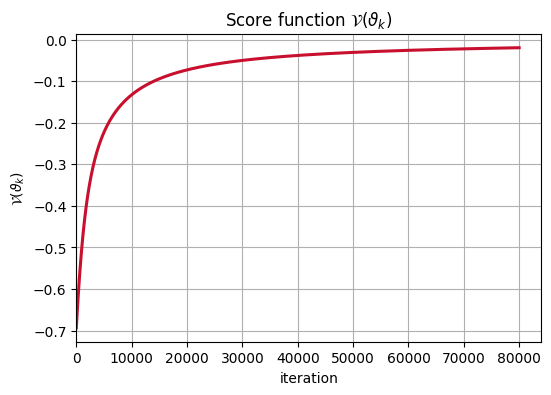

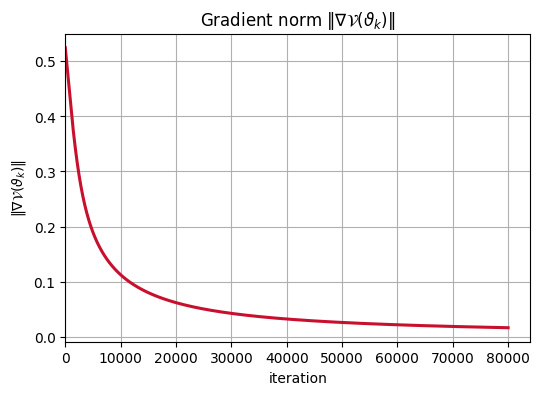

In [ ]:
# Style controls
score_color = "#C8102E"
score_linewidth = 2.2

grad_color = "#C8102E"
grad_linewidth = 2.2

# Score plot
plt.figure(figsize=(6, 4))
plt.plot(
    results["history_score_rkhs"],
    color=score_color,
    linewidth=score_linewidth,
)
plt.xlim(left=0)
plt.title(r"Score function $\mathcal{V}(\vartheta_k)$")
plt.xlabel("iteration")
plt.ylabel(r"$\mathcal{V}(\vartheta_k)$")
plt.grid(True)
plt.show()

# Gradient norm plot
plt.figure(figsize=(6, 4))
plt.plot(
    results["history_grad_norm_rkhs"],
    color=grad_color,
    linewidth=grad_linewidth,
)
plt.xlim(left=0)
plt.title(r"Gradient norm $\|\nabla \mathcal{V}(\vartheta_k)\|$")
plt.xlabel("iteration")
plt.ylabel(r"$\|\nabla \mathcal{V}(\vartheta_k)\|$")
plt.grid(True)
plt.show()

## Plotting selected recovered policy probabilities

This code cell plots selected entries of the recovered policy during the RKHS gradient-ascent iterations.

For each parameter $\vartheta_k$, the inverse algorithm computes a recovered soft policy

$$
\pi_{\vartheta_k}(a\mid x).
$$

The plot shows how some selected probabilities evolve as the reward parameter is updated. This is useful for seeing whether the recovered policy gradually assigns larger probability to the actions selected by the expert.

The expert policy $\pi_E$ is obtained from the hard Bellman equation:

$$
\pi_E(a\mid x)>0
\quad\Longleftrightarrow\quad
a\in\arg\max_b Q_E(x,b).
$$

Thus, in this example, $\pi_E$ is deterministic. In contrast, the recovered policy is obtained from the soft Bellman equation:

$$
\pi_\vartheta(a\mid x)
=
\frac{\exp(Q_\vartheta(x,a))}
{\sum_b \exp(Q_\vartheta(x,b))}.
$$

Therefore, $\pi_\vartheta$ is generally stochastic. A good recovery does not necessarily mean that $\pi_\vartheta$ becomes exactly deterministic. Rather, it means that $\pi_\vartheta$ assigns high probability to the expert actions.

If the purpose of the plot is to track the recovered probabilities of the expert actions, then the selected action for each state should be chosen according to the final expert policy. In this experiment, the expert policy is

$$
\pi_E=
\begin{bmatrix}
1&0\\
1&0\\
0&1\\
1&0
\end{bmatrix}.
$$

Hence the expert actions are

$$
a_E(0)=0,
\qquad
a_E(1)=0,
\qquad
a_E(2)=1,
\qquad
a_E(3)=0.
$$

So the corresponding dictionary should be

```python
action_for_state = {
    0: 0,
    1: 0,
    2: 1,
    3: 0,
}
```

With this choice, the plot shows whether the recovered soft policy increasingly concentrates on the same actions as the hard expert policy.

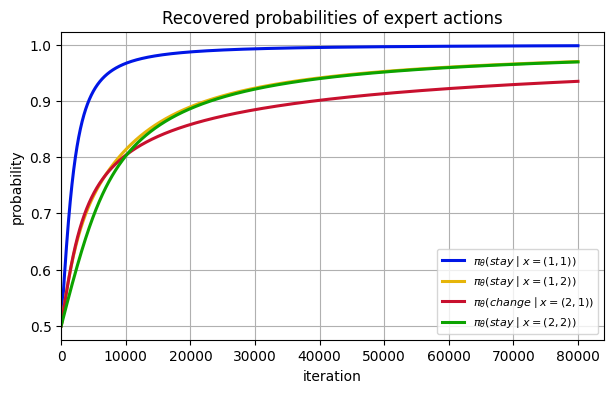

In [6]:
plt.figure(figsize=(7, 4))
ax = plt.gca()

action_for_state = {
    0: 0,
    1: 0,
    2: 1,
    3: 0,
}

curve_colors = {
    0: "#0016E6",  # state (1,1)
    1: "#E6B509",  # state (1,2)
    2: "#C8102E",  # state (2,1)
    3: "#0CA300",  # state (2,2)
}

curve_linewidth = 2.2

for x in range(len(params["states"])):
    a = action_for_state[x]

    state_tuple = params["states"][x]
    state_label = rf"({state_tuple[0]},{state_tuple[1]})"

    label = rf"$\pi_\theta({params['actions'][a]} \mid x={state_label})$"

    plt.plot(
        results["history_pi_entries_rkhs"][(x, a)],
        label=label,
        color=curve_colors[x],
        linewidth=curve_linewidth,
    )

plt.xlim(left=0)
plt.title("Recovered probabilities of expert actions")
plt.xlabel("iteration")
plt.ylabel("probability")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.show()

## Plotting the mean-field error and RKHS feature-moment error

This code cell plots two error histories stored by `run_pipeline`.

The first one is

```python
results["history_mu_error_rkhs"]
```

At each RKHS iteration, the code computes

$$
\|\mu_{\vartheta_k}-\mu_E\|_1.
$$

Here $\mu_{\vartheta_k}$ is not chosen manually. It is computed inside `solve_policy_from_theta` as the invariant distribution of the Markov chain induced by the current recovered soft policy $\pi_{\vartheta_k}$.

For a current policy $\pi_{\vartheta_k}$, the induced transition matrix is

$$
P_{\pi_{\vartheta_k}}^{\mu_E}(y\mid x)
=
\sum_a
\pi_{\vartheta_k}(a\mid x)
p(y\mid x,a,\mu_E).
$$

Then the code solves

$$
\mu_{\vartheta_k}^\top
P_{\pi_{\vartheta_k}}^{\mu_E}
=
\mu_{\vartheta_k}^\top.
$$

So the first plotted curve measures whether the recovered policy generates a stationary state distribution close to the expert mean field.

The second history is

```python
results["history_phi_error_rkhs"]
```

At each RKHS iteration, the code computes

$$
\|\langle\phi\rangle_{\vartheta_k}
-
\langle\phi\rangle_E\|.
$$

The expert RKHS moment is

$$
\langle\phi\rangle_E
=
\sum_{x,a}
\nu_E(x,a)\Phi(x,a,\mu_E),
$$

where

$$
\nu_E(x,a)
=
\mu_E(x)\pi_E(a\mid x).
$$

The recovered RKHS moment is

$$
\langle\phi\rangle_{\vartheta_k}
=
\sum_{x,a}
\nu_{\vartheta_k}(x,a)\Phi(x,a,\mu_E),
$$

where

$$
\nu_{\vartheta_k}(x,a)
=
\mu_{\vartheta_k}(x)
\pi_{\vartheta_k}(a\mid x).
$$

The function `rkhs_moment_from_nu(nu, mu, basis_points, params)` computes these RKHS moments by summing the kernel feature vectors weighted by the occupation measure.

These two errors are central to the algorithm because they are exactly the two blocks of the gradient:

$$
\nabla\mathcal V(\vartheta_k)
=
\left(
\mu_E-\mu_{\vartheta_k},
\langle\phi\rangle_E-\langle\phi\rangle_{\vartheta_k}
\right).
$$

Therefore, when these curves decrease, the algorithm is directly reducing the expert-statistic mismatch.

This plot is therefore more than a visual check. It shows whether the recovered policy is satisfying the two inverse constraints: matching the expert mean field and matching the expert RKHS feature moments.

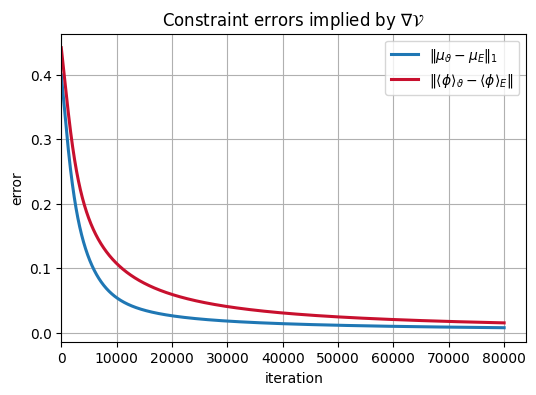

In [ ]:
# Style controls
mu_error_color = "#1f77b4"
mu_error_linewidth = 2.2

phi_error_color = "#C8102E"
phi_error_linewidth = 2.2


# Constraint error plot
plt.figure(figsize=(6, 4))

plt.plot(
    results["history_mu_error_rkhs"],
    label=r"$\|\mu_\vartheta-\mu_E\|_1$",
    color=mu_error_color,
    linewidth=mu_error_linewidth,
)

plt.plot(
    results["history_phi_error_rkhs"],
    label=r"$\|\langle\phi\rangle_\vartheta-\langle\phi\rangle_E\|$",
    color=phi_error_color,
    linewidth=phi_error_linewidth,
)

plt.xlim(left=0)
plt.title(r"Constraint errors implied by $\nabla \mathcal{V}$")
plt.xlabel("iteration")
plt.ylabel("error")
plt.legend()
plt.grid(True)
plt.show()

## Displaying the final expert and recovered objects

This final code cell displays four objects from the dictionary `results`:

```python
results["mu_E"]
results["pi_E"]
results["mu_theta"]
results["pi_theta"]
```

The first two objects,

$$
\mu_E
\qquad
\text{and}
\qquad
\pi_E,
$$

come from the forward MFE solve.

The pair $(\pi_E,\mu_E)$ is generated using the true reward. It is the synthetic expert MFE. The code verifies it by checking that $\pi_E$ is greedy with respect to $Q_E$ and that $\mu_E$ is the invariant distribution of the Markov chain induced by $\pi_E$.

The last two objects,

$$
\mu_\vartheta
\qquad
\text{and}
\qquad
\pi_\vartheta,
$$

come from the final RKHS reward parameter learned by the inverse algorithm.

The recovered reward has the form

$$
r_\vartheta(x,a,\mu_E)
=
\zeta_x+
\sum_i c_i k((x,a,\mu_E),z_i).
$$

For this recovered reward, the code solves the soft Bellman equation

$$
Q_\vartheta(x,a)
=
r_\vartheta(x,a,\mu_E)
+
\sum_y
\tilde p(y\mid x,a,\mu_E)
V_\vartheta(y),
$$

where

$$
V_\vartheta(x)
=
\log\sum_b
\exp(Q_\vartheta(x,b)).
$$

Then the recovered policy is

$$
\pi_\vartheta(a\mid x)
=
\frac{\exp(Q_\vartheta(x,a))}
{\sum_b\exp(Q_\vartheta(x,b))}.
$$

Finally, the recovered mean field $\mu_\vartheta$ is computed as the invariant distribution of the Markov chain induced by $\pi_\vartheta$:

$$
\mu_\vartheta^\top
P_{\pi_\vartheta}^{\mu_E}
=
\mu_\vartheta^\top.
$$

Therefore, the final display compares

$$
(\pi_E,\mu_E)
$$

from the true-reward forward MFE problem with

$$
(\pi_\vartheta,\mu_\vartheta)
$$

from the recovered RKHS reward.

The comparison should be interpreted carefully. The expert policy is hard and greedy, while the recovered policy is soft and entropy-regularized. Therefore exact equality of the two policies is not expected. The correct questions are:

$$
\mu_\vartheta \approx \mu_E?
$$

$$
\langle\phi\rangle_\vartheta \approx \langle\phi\rangle_E?
$$

and

$$
\pi_\vartheta
\text{ puts high probability on the expert greedy actions?}
$$

These are exactly the quantities reported and plotted in the previous cells.

In [8]:
results["mu_E"], results["pi_E"], results["mu_theta"], results["pi_theta"]

(array([0.45, 0.25, 0.05, 0.25]),
 array([[1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.]]),
 array([0.446522, 0.250468, 0.053478, 0.249532]),
 array([[0.998078, 0.001922],
        [0.969867, 0.030133],
        [0.06524 , 0.93476 ],
        [0.969284, 0.030716]]))

## Interpretation and limitations of the numerical experiment

This notebook verifies a full synthetic RKHS maximum entropy IRL pipeline.

First, the code defines a finite stationary mean-field game with four states and two actions. The true reward depends on the current mean field through provider shares, and the transition kernel includes noise to ensure irreducibility and to provide the minorization lower bound used in the average-reward Bellman equations.

Second, the code solves the forward MFE problem. For each candidate mean field $\mu$, it solves the frozen representative-agent MDP using the hard Bellman equation. This gives a greedy policy $\pi_\mu$. Then it computes the invariant distribution $\hat\mu$ generated by that policy. The forward fixed-point iteration continues until

$$
\hat\mu\approx \mu.
$$

At convergence, the returned pair satisfies the two MFE conditions numerically:

$$
\pi_E
\text{ is optimal for } \mu_E,
$$

and

$$
\mu_E
\text{ is invariant under } \pi_E.
$$

Third, the code converts the expert MFE into expert statistics. It computes the occupation measure

$$
\nu_E(x,a)=\mu_E(x)\pi_E(a\mid x)
$$

and the RKHS feature moment

$$
\langle\phi\rangle_E
=
\sum_{x,a}
\nu_E(x,a)\Phi(x,a,\mu_E).
$$

Fourth, the code constructs a finite RKHS reward model. The basis points are

$$
z_i=(x,a,\mu_E),
$$

and the learned reward has the form

$$
r_\vartheta(x,a,\mu_E)
=
\zeta_x+
\sum_i c_i k((x,a,\mu_E),z_i).
$$

Fifth, the code performs maximum entropy IRL. For every parameter $\vartheta$, it solves a soft Bellman equation, obtains a soft policy $\pi_\vartheta$, computes its invariant distribution $\mu_\vartheta$, forms the occupation measure $\nu_\vartheta$, and computes the recovered RKHS feature moment $\langle\phi\rangle_\vartheta$.

The score optimized by gradient ascent is

$$
\mathcal V(\vartheta)
=
\sum_{x,a}
\nu_E(x,a)\log\pi_\vartheta(a\mid x).
$$

The gradient is

$$
\nabla\mathcal V(\vartheta)
=
\left(
\mu_E-\mu_\vartheta,
\langle\phi\rangle_E-\langle\phi\rangle_\vartheta
\right).
$$

Thus, the update directly tries to match the expert mean field and the expert RKHS feature moments.

The RKHS coefficient update uses the Gram correction

$$
c_{k+1}
=
c_k+\gamma G^{-1}
\left(
\langle\phi\rangle_E-\langle\phi\rangle_{\vartheta_k}
\right),
$$

because the RKHS inner product in coefficient coordinates is

$$
\langle \psi_c,\psi_d\rangle_{\mathcal H_k}
=
c^\top Gd.
$$

The final result should be stated precisely. The code does not prove that the MFE is unique. It also does not prove global convergence from every initial mean field. What it does show is that, for this constructed example, one numerically verified expert MFE is computed and the RKHS inverse procedure recovers a soft policy whose induced mean field and RKHS feature moments are close to the expert quantities.